<a href="https://colab.research.google.com/github/Katya1985/1/blob/master/%22%D0%92%D0%B2%D0%B5%D0%B4%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B2_Google_Colab%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Создание и настройка документа
# Введение в Google Colab
# Текстовые и кодовые ячейки:

Google Colab — это бесплатная облачная платформа от Google для машинного обучения и анализа данных. Она позволяет выполнять код на Python в браузере с использованием облачных ресурсов.

In [ ]:

print("Hello, Google Colab!")

Hello, Google Colab!


In [ ]:
# Основы Python:
# список из 10 случайных чисел
import random
random_number = [random.randint(1, 100) for i in range(10)]

# функция, которая возвращает сумму чисел в списке
def sum_of_numbers(numbers):
  return sum(numbers)

# Вызов функции и вывод результата на экран
result = sum_of_numbers(random_number)
print("Список случайных чисел:", random_number)
print("Сумма чисел в списке:", result)

Список случайных чисел: [92, 6, 63, 36, 43, 41, 13, 91, 12, 81]
Сумма чисел в списке: 478


In [ ]:
# Работа с библиотеками:
# Установка библиотеки numpy
!pip install numpy

# Импорт библиотеки numpy и создание массива из 20 случайных чисел
import numpy as np
random_array = np.random.randint(1, 100, size = 20)

# Вычисление среднего значения массива и вывод его на экран
mean_value = np.mean(random_array)
print("Массив случайных чисел", random_array)
print("Среднее значение массива", mean_value)


Массив случайных чисел [13 32 31 15  6 44  8 92 69 45 83 89 84 62 53 69 52 95 93 27]
Среднее значение массива 53.1


  Month   "1958"   "1959"   "1960"
0   JAN      340      360      417
1   FEB      318      342      391
2   MAR      362      406      419
3   APR      348      396      461
4   MAY      363      420      472


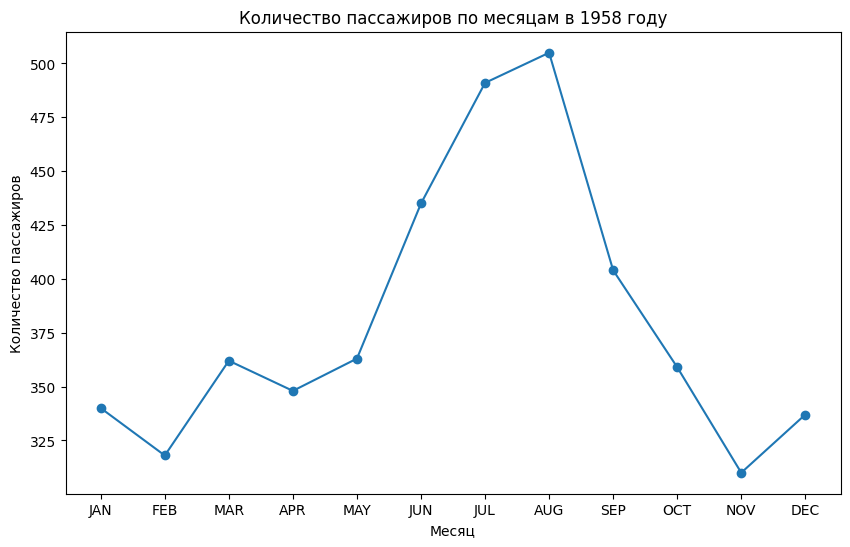

In [ ]:
# Установка библиотеки pandas
!pip install pandas

# Импорт библиотеки pandas
import pandas as pd

#Загрузка данных:
# Загрузка CSV файла из интернета
url = "https://people.sc.fsu.edu/~jburkardt/data/csv/airtravel.csv"
data = pd.read_csv(url)
print(data.head(5))

# Визуализация данных:
# Установка библиотеки matplotlib
!pip install matplotlib

# Постройка простого графика на основе данных из вашего CSV файла:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(data['Month'], data[' "1958"'], marker='o', linestyle='-')
plt.title('Количество пассажиров по месяцам в 1958 году')
plt.xlabel('Месяц')
plt.ylabel('Количество пассажиров')
plt.show()

In [ ]:
# Использование генетических алгоритмов:
# Копируем код генетического алгоритма из лекционного блокнота
# Запустили его, изучили работу кода
# Изменяем значение целевой переменной TARGET. Добиваемся
#  (увеличивая при необходимости число итераций обучения)
#  полного соответствия "нового индивида целевой переменной"
import random

# Количество особей в каждом поколении
POPULATION_SIZE = 100

# Валидные гены
GENES = '''abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOP
QRSTUVWXYZ 1234567890, .-;:_!"#%&/()=?@${[]}'''

# Целевая строка для генерации
TARGET = "In principio erat Verbum 2000"

class Individual(object):
	'''
	Класс, представляющий отдельную особь (индивида) в популяции
	'''
	def __init__(self, chromosome):
		self.chromosome = chromosome
		self.fitness = self.cal_fitness()

	@classmethod
	def mutated_genes(self):
		'''
		Создаем случайные гены для мутации
		'''
		global GENES
		gene = random.choice(GENES)
		return gene

	@classmethod
	def create_gnome(self):
		'''
		Создаем хромосому или набор генов
		'''
		global TARGET
		gnome_len = len(TARGET)
		return [self.mutated_genes() for _ in range(gnome_len)]

	def gene_transfer(self, par2):
		'''
		Передаем гены новому поколению индивидов
		'''

		child_chromosome = []
		for gp1, gp2 in zip(self.chromosome, par2.chromosome):

			prob = random.random()

			# если вероятность меньше 0,45, берем ген
			# от родителя 1
			if prob < 0.45:
				child_chromosome.append(gp1)

			# если вероятность между 0.45 и 0.90, берем
			# ген от родителя 2
			elif prob < 0.90:
				child_chromosome.append(gp2)

			# в противном случае берем случайный ген (мутация),
			else:
				child_chromosome.append(self.mutated_genes())


		return Individual(child_chromosome)

	def cal_fitness(self):
		'''
		Рассчитываем показатель соответствия, это количество
		символов в строке, которые отличаются от целевой
		строки.
		'''
		global TARGET
		fitness = 0
		for gs, gt in zip(self.chromosome, TARGET):
			if gs != gt: fitness+= 1
		return fitness

# Driver code
def main():
	global POPULATION_SIZE

	#Текущее поколение
	generation = 1

	found = False
	population = []

	# Новое поколение
	for _ in range(POPULATION_SIZE):
				gnome = Individual.create_gnome()
				population.append(Individual(gnome))

	while not found:

		# Отсортируем популяцию в порядке возрастания оценки соответствия целевой функции
		population = sorted(population, key = lambda x:x.fitness)

		# Если у нас появился индивид, достигший целевой функции
		# цикл совершенствования можно прервать
		if population[0].fitness <= 0:
			found = True
			break

		# В противном случае - продолжаем создавать новые поколения
		new_generation = []

		# Определяем 10% популяции, наиболее соответствующих целевой фукнции
		# чтобы передать их гены будущим поколениям
		s = int((10*POPULATION_SIZE)/100)
		new_generation.extend(population[:s])


		s = int((90*POPULATION_SIZE)/100)
		for _ in range(s):
			parent1 = random.choice(population[:50])
			parent2 = random.choice(population[:50])
			child = parent1.gene_transfer(parent2)
			new_generation.append(child)

		population = new_generation

		print("Generation: {}\tString: {}\tFitness: {}".
			format(generation,
			"".join(population[0].chromosome),
			population[0].fitness))

		generation += 1


	print("Generation: {}\tString: {}\tFitness: {}".
		format(generation,
		"".join(population[0].chromosome),
		population[0].fitness))

if __name__ == '__main__':
	main()




Generation: 1	String: ,V
joX6l411o ?ce[cPl$qimJtIq7	Fitness: 26
Generation: 2	String: ,V
joX6l411o ?ce[cPl$qimJtIq7	Fitness: 26
Generation: 3	String: P
I%4w!.-1Kok@Q2w YTgWfmS{08 	Fitness: 25
Generation: 4	String: P
I%4w!.-1Kok@Q2w YTgWfmS{08 	Fitness: 25
Generation: 5	String: P
I%4w!.-1Kok@Q2w YTgWfmS{08 	Fitness: 25
Generation: 6	String: $n %sX9l,.EE lcaD u rV
me?5P7	Fitness: 22
Generation: 7	String: $n %sX9l,.EE lcaD u rV
me?5P7	Fitness: 22
Generation: 8	String: Ln RzW6a1p1E %8aD 4Xr)im&?e!,	Fitness: 21
Generation: 9	String: I!aIzvUd
4vo Oca[ u/rb
m;{0==	Fitness: 20
Generation: 10	String: I!aIzvUd
4vo Oca[ u/rb
m;{0==	Fitness: 20
Generation: 11	String: I!aIzvUd
4vo Oca[ u/rb
m;{0==	Fitness: 20
Generation: 12	String: Ina$Uh6v!-9o ecaY L.
bpm-e0&4	Fitness: 19
Generation: 13	String: InaIYq6;Spvo Wwaw _/rbBmfvId0	Fitness: 18
Generation: 14	String: InaIYq6;Spvo Wwaw _/rbBmfvId0	Fitness: 18
Generation: 15	String: InaIYq6;Spvo Wwaw _/rbBmfvId0	Fitness: 18
Generation: 16	String: In HY,nU6B1